In [1]:
!pip -q install torch torchvision matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.89MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.12MB/s]


Train samples: 60000
Test samples: 10000


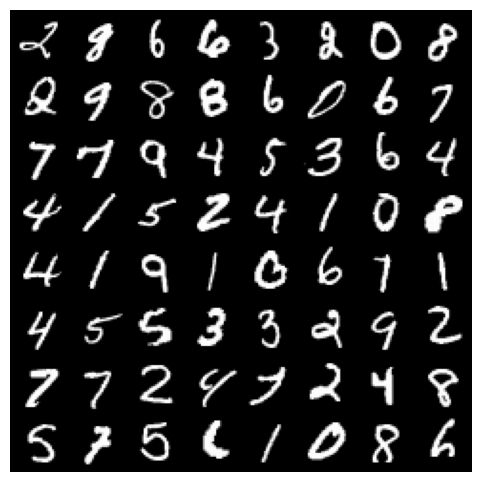

In [3]:
dataiter = iter(train_loader)
images, labels = next(dataiter)

plt.figure(figsize=(6,6))
grid = torchvision.utils.make_grid(images[:64], nrow=8, normalize=True)
plt.imshow(np.transpose(grid.cpu(), (1,2,0)))
plt.axis("off")
plt.show()

In [4]:
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 400),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 28*28),
            nn.Tanh()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        x_enc = self.encoder(x)
        mu = self.fc_mu(x_enc)
        logvar = self.fc_logvar(x_enc)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        recon = recon.view(-1, 1, 28, 28)
        return recon, mu, logvar

vae = VAE(latent_dim=20).to(device)

In [5]:
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss

In [6]:
optimizer = optim.Adam(vae.parameters(), lr=1e-3)
epochs = 20
train_losses = []

In [7]:
vae.train()

for epoch in range(epochs):
    total_loss = 0

    for images, _ in train_loader:
        images = images.to(device)

        optimizer.zero_grad()
        recon, mu, logvar = vae(images)
        loss = vae_loss(recon, images, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.4f}")

Epoch [1/20] Loss: 121.4833
Epoch [2/20] Loss: 81.8771
Epoch [3/20] Loss: 76.7490
Epoch [4/20] Loss: 74.2322
Epoch [5/20] Loss: 72.5635
Epoch [6/20] Loss: 71.4136
Epoch [7/20] Loss: 70.5624
Epoch [8/20] Loss: 69.9093
Epoch [9/20] Loss: 69.3703
Epoch [10/20] Loss: 68.8420
Epoch [11/20] Loss: 68.4472
Epoch [12/20] Loss: 68.0647
Epoch [13/20] Loss: 67.7824
Epoch [14/20] Loss: 67.4836
Epoch [15/20] Loss: 67.2126
Epoch [16/20] Loss: 66.8900
Epoch [17/20] Loss: 66.7725
Epoch [18/20] Loss: 66.5139
Epoch [19/20] Loss: 66.2876
Epoch [20/20] Loss: 66.1510


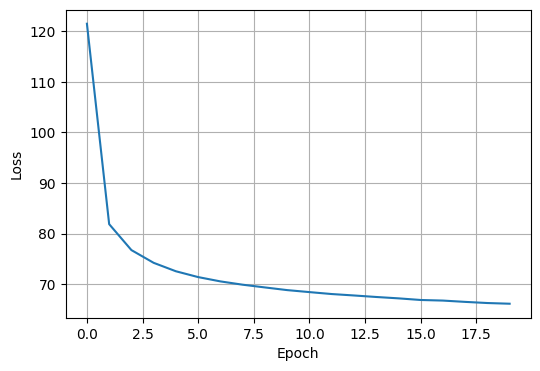

In [8]:
plt.figure(figsize=(6,4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.savefig("vae_loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

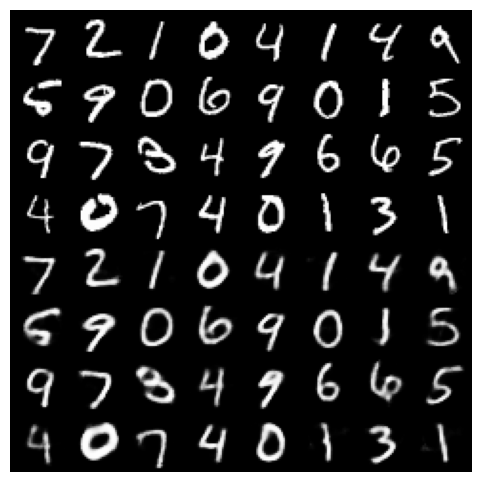

In [9]:
vae.eval()

with torch.no_grad():
    images, _ = next(iter(test_loader))
    images = images.to(device)

    recon, _, _ = vae(images)
    comparison = torch.cat([images[:32], recon[:32]])

    plt.figure(figsize=(6,6))
    grid = torchvision.utils.make_grid(comparison.cpu(), nrow=8, normalize=True)
    plt.imshow(np.transpose(grid, (1,2,0)))
    plt.axis("off")
    plt.savefig("vae_reconstructions.png", dpi=300, bbox_inches="tight")
    plt.show()

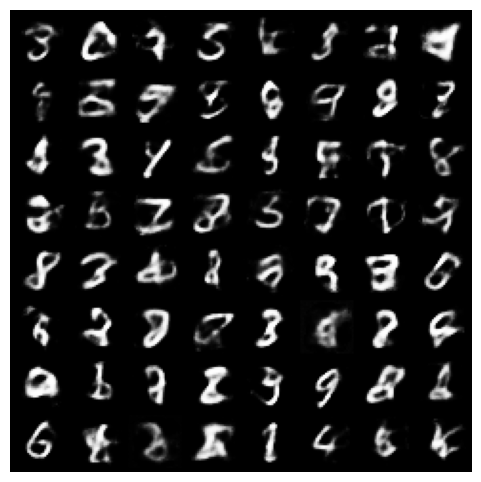

In [10]:
with torch.no_grad():
    z = torch.randn(64, 20).to(device)
    samples = vae.decoder(z).view(-1,1,28,28)

plt.figure(figsize=(6,6))
grid = torchvision.utils.make_grid(samples.cpu(), nrow=8, normalize=True)
plt.imshow(np.transpose(grid, (1,2,0)))
plt.axis("off")
plt.savefig("vae_generated_samples.png", dpi=300, bbox_inches="tight")
plt.show()

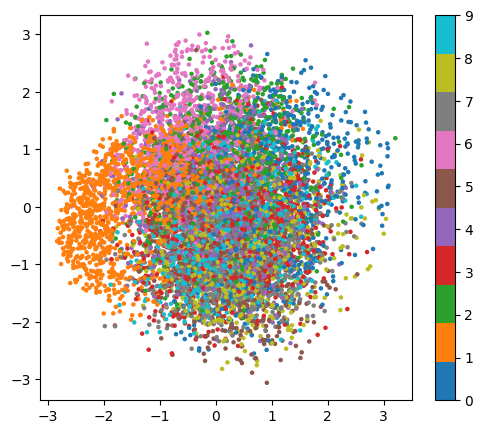

In [11]:
vae.eval()

latents = []
labels_list = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        mu = vae.fc_mu(vae.encoder(images))
        latents.append(mu.cpu())
        labels_list.append(labels)

latents = torch.cat(latents).numpy()
labels_list = torch.cat(labels_list).numpy()

plt.figure(figsize=(6,5))
plt.scatter(latents[:,0], latents[:,1], c=labels_list, cmap="tab10", s=5)
plt.colorbar()
plt.savefig("vae_latent_space.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
torch.save(vae.state_dict(), "vae_mnist_model.pth")
print("Model saved.")

Model saved.
